# 🔐 Fraud Detection — End-to-End **Deep Learning** Pipeline (Memory-Efficient)

| | |
|---|---|
| **Nama** | Rangga Timotius |
| **NIM** | 101032300137 |
| **Kelas** | TK46GAB |

---
## 📌 Deskripsi Proyek
Dataset berisi transaksi e-commerce berlabel `isFraud` (0=normal, 1=fraud).
**Tujuan:** memprediksi probabilitas fraud menggunakan **deep learning**, dengan hyperparameter tuning otomatis (**Optuna**) dan experiment tracking (**MLflow**).

> ⚡ Notebook ini dioptimasi untuk Colab Free (RAM terbatas) dengan teknik:
> - **dtype downcasting** (float64 → float32, int64 → int32)
> - **Seleksi kolom** sebelum load penuh
> - **Sampling stratified** jika RAM masih tidak cukup
> - **Hapus variabel** yang tidak dipakai dengan `del` + `gc.collect()`

**Update dari versi sebelumnya:** model machine learning klasik (Logistic Regression, Random Forest, XGBoost + RandomizedSearchCV) diganti dengan **tiga arsitektur deep learning** (Shallow MLP, Deep MLP, Deep Residual MLP), tuning hyperparameter memakai **Optuna**, dan seluruh eksperimen dicatat dengan **MLflow**. Bagian loading data, EDA, dan preprocessing **tidak diubah** karena sudah berjalan baik di data lengkap.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. 🔗 Mount Google Drive & Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil di-mount!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount!


In [3]:
!pip install imbalanced-learn optuna mlflow -q
print("✅ Library siap!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, average_precision_score)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import optuna
import mlflow

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ Semua library berhasil di-import! (TensorFlow:", tf.__version__, "| Optuna:", optuna.__version__, "| MLflow:", mlflow.__version__, ")")

✅ Semua library berhasil di-import! (TensorFlow: 2.20.0 | Optuna: 4.9.0 | MLflow: 3.14.0 )


## 2. 📂 Load Data (Memory-Efficient)

In [5]:
# ⚠️ SESUAIKAN PATH INI
DRIVE_PATH = '/content/drive/MyDrive/'   # ganti jika di subfolder

TRAIN_PATH = DRIVE_PATH + 'train_transaction.csv'
TEST_PATH  = DRIVE_PATH + 'test_transaction.csv'


In [6]:
# ── Fungsi untuk downcast dtype ──
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type).startswith('int'):
                for dtype in [np.int8, np.int16, np.int32]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
            else:
                for dtype in [np.float16, np.float32]:
                    if c_min > np.finfo(dtype).min and c_max < np.finfo(dtype).max:
                        df[col] = df[col].astype(dtype); break
    end_mem = df.memory_usage().sum() / 1024**2
    print(f"  Memori: {start_mem:.1f} MB → {end_mem:.1f} MB ({100*(start_mem-end_mem)/start_mem:.1f}% hemat)")
    return df


In [7]:
# ── Cek kolom & ukuran dulu tanpa load semua data ──
print("Membaca header untuk cek kolom...")
train_cols = pd.read_csv(TRAIN_PATH, nrows=0).columns.tolist()
print(f"Jumlah kolom train : {len(train_cols)}")
print(f"Kolom target       : {'isFraud' in train_cols}")


Membaca header untuk cek kolom...
Jumlah kolom train : 394
Kolom target       : True


In [8]:
# ── Pilih kolom yang akan dipakai (buang kolom V yang terlalu banyak) ──
# Kolom V (V1-V339) adalah hasil PCA — ambil subset saja untuk hemat RAM
import re
v_cols = [c for c in train_cols if re.match(r'^V\d+$', c)]
# Ambil setiap 3 kolom V (V1,V4,V7,...) untuk representasi
v_selected = v_cols[::3]

# Kolom utama non-V
core_cols = [c for c in train_cols if not re.match(r'^V\d+$', c)]

USE_COLS = core_cols + v_selected
print(f"Total kolom dipilih : {len(USE_COLS)} dari {len(train_cols)}")
print(f"  - Core cols : {len(core_cols)}")
print(f"  - V cols    : {len(v_selected)} (dari {len(v_cols)} total)")


Total kolom dipilih : 168 dari 394
  - Core cols : 55
  - V cols    : 113 (dari 339 total)


In [9]:
# ── Load train dengan kolom terpilih ──
print("Loading train_transaction.csv (kolom terpilih)...")
train = pd.read_csv(TRAIN_PATH, usecols=USE_COLS)
train = reduce_mem_usage(train)
print(f"✅ Train shape : {train.shape}")
gc.collect()


Loading train_transaction.csv (kolom terpilih)...
  Memori: 756.9 MB → 256.2 MB (66.1% hemat)
✅ Train shape : (590540, 168)


150

In [10]:
# ── Load test ──
test_use_cols = [c for c in USE_COLS if c != 'isFraud']
print("Loading test_transaction.csv...")
test = pd.read_csv(TEST_PATH, usecols=[c for c in test_use_cols if c in pd.read_csv(TEST_PATH, nrows=0).columns])
test = reduce_mem_usage(test)
print(f"✅ Test shape  : {test.shape}")
gc.collect()


Loading test_transaction.csv...
  Memori: 645.6 MB → 221.3 MB (65.7% hemat)
✅ Test shape  : (506691, 167)


0

## 3. 📊 Eksplorasi Data (EDA)

In [11]:
print("=== Distribusi Target (isFraud) ===")
vc = train['isFraud'].value_counts()
print(vc)
fraud_pct = vc[1] / len(train) * 100
print(f"\nFraud  : {fraud_pct:.2f}%")
print(f"Normal : {100-fraud_pct:.2f}%")
print("\n⚠️ Dataset sangat imbalanced!" if fraud_pct < 5 else "")


=== Distribusi Target (isFraud) ===
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud  : 3.50%
Normal : 96.50%

⚠️ Dataset sangat imbalanced!


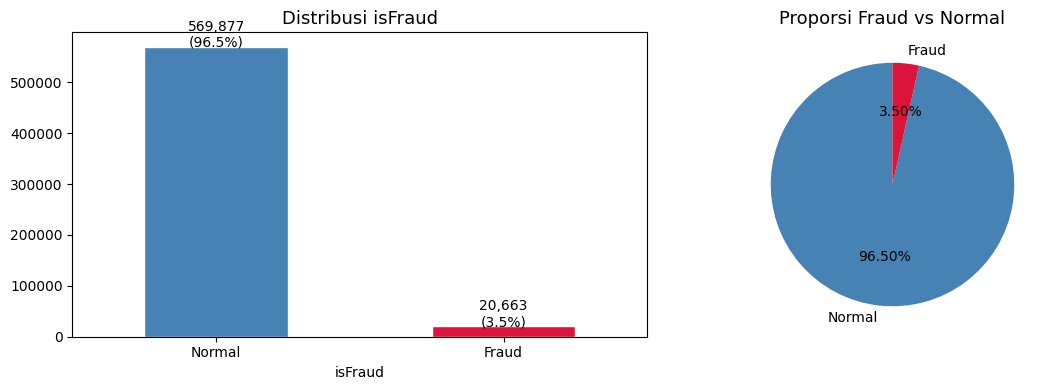

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc.plot(kind='bar', ax=axes[0], color=['steelblue','crimson'], edgecolor='white', width=0.5)
axes[0].set_title('Distribusi isFraud', fontsize=13)
axes[0].set_xticklabels(['Normal','Fraud'], rotation=0)
for i, v in enumerate(vc):
    axes[0].text(i, v+200, f'{v:,}\n({v/len(train)*100:.1f}%)', ha='center', fontsize=10)

axes[1].pie(vc, labels=['Normal','Fraud'], autopct='%1.2f%%',
            colors=['steelblue','crimson'], startangle=90)
axes[1].set_title('Proporsi Fraud vs Normal', fontsize=13)
plt.tight_layout(); plt.show()


In [13]:
print("=== Missing Values (Top 15) ===")
miss = train.isnull().mean().sort_values(ascending=False).head(15)
print((miss * 100).round(2).to_string())


=== Missing Values (Top 15) ===
dist2    93.63
D7       93.41
D13      89.51
D14      89.47
D12      89.04
D6       87.61
D9       87.31
D8       87.31
V148     86.12
V154     86.12
V157     86.12
V139     86.12
V142     86.12
V163     86.12
V166     86.12


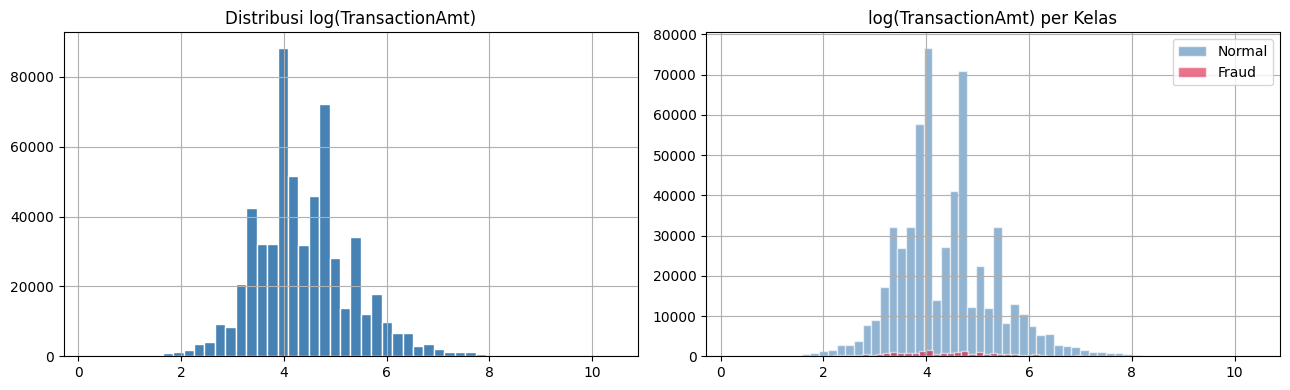

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
np.log1p(train['TransactionAmt']).hist(bins=50, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribusi log(TransactionAmt)', fontsize=12)

for label, color in [(0,'steelblue'),(1,'crimson')]:
    np.log1p(train[train['isFraud']==label]['TransactionAmt']).hist(
        bins=60, alpha=0.6, color=color, edgecolor='white',
        label='Normal' if label==0 else 'Fraud', ax=axes[1])
axes[1].set_title('log(TransactionAmt) per Kelas', fontsize=12)
axes[1].legend()
plt.tight_layout(); plt.show()


## 4. 🔧 Preprocessing

In [15]:
# Pisahkan target & TransactionID
y = train['isFraud'].astype(np.int8)
test_ids = test['TransactionID'].copy()

X = train.drop(columns=['isFraud'])
del train; gc.collect()   # ← bebaskan RAM segera
print(f"✅ train dihapus dari RAM | X shape: {X.shape}")


✅ train dihapus dari RAM | X shape: (590540, 167)


In [16]:
# Hapus kolom missing > 70%
thresh = 0.70
drop_cols = X.columns[X.isnull().mean() > thresh].tolist()
print(f"Kolom dihapus (missing > 70%): {len(drop_cols)}")
X = X.drop(columns=drop_cols)
test = test.drop(columns=[c for c in drop_cols if c in test.columns])
print(f"Shape setelah drop: {X.shape}")


Kolom dihapus (missing > 70%): 62
Shape setelah drop: (590540, 105)


In [17]:
# Encoding kategorikal
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal: {len(cat_cols)}")

le = LabelEncoder()
for col in cat_cols:
    all_vals = pd.concat([X[col], test[col] if col in test.columns else pd.Series()]).astype(str)
    le.fit(all_vals)
    X[col]   = le.transform(X[col].astype(str)).astype(np.int16)
    if col in test.columns:
        test[col] = le.transform(test[col].astype(str)).astype(np.int16)

print("✅ Label Encoding selesai")


Kolom kategorikal: 13
✅ Label Encoding selesai


In [18]:
# Imputasi median
print("Imputasi missing values (median)...")
num_cols = X.select_dtypes(include=np.number).columns.tolist()
imputer = SimpleImputer(strategy='median')
X[num_cols]    = imputer.fit_transform(X[num_cols]).astype(np.float32)

test_num = [c for c in num_cols if c in test.columns]
test[test_num] = imputer.transform(test[test_num]).astype(np.float32)

print(f"✅ Imputasi selesai. Missing: {X.isnull().sum().sum()}")
gc.collect()


Imputasi missing values (median)...
✅ Imputasi selesai. Missing: 0


0

In [19]:
# Feature engineering
X['log_TransactionAmt']    = np.log1p(X['TransactionAmt']).astype(np.float32)
test['log_TransactionAmt'] = np.log1p(test['TransactionAmt']).astype(np.float32)
print("✅ Feature engineering selesai")
print(f"RAM train X: {X.memory_usage().sum()/1024**2:.1f} MB")


✅ Feature engineering selesai
RAM train X: 238.8 MB


## 5. ⚖️ Split Data & Handle Class Imbalance

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
del X; gc.collect()
print(f"Train : {X_train.shape[0]:,} | Val : {X_val.shape[0]:,}")
print(f"Fraud rate train : {y_train.mean()*100:.2f}%")


Train : 472,432 | Val : 118,108
Fraud rate train : 3.50%


In [21]:
# SMOTE — terapkan pada training set saja
print("Menerapkan SMOTE...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
del X_train; gc.collect()

print(f"Shape setelah SMOTE : {X_train_sm.shape}")
print(f"Distribusi:\n{pd.Series(y_train_sm).value_counts()}")


Menerapkan SMOTE...
Shape setelah SMOTE : (911804, 106)
Distribusi:
isFraud
0    455902
1    455902
Name: count, dtype: int64


## 6. 🤖 Arsitektur Deep Learning (Baseline)

Tiga arsitektur dibandingkan — tema **shallow vs deep**:

| Arsitektur | Karakteristik |
|---|---|
| **Shallow MLP** | 1 hidden layer — baseline paling sederhana |
| **Deep MLP** | 4 hidden layer dengan BatchNormalization + Dropout |
| **Deep Residual MLP** | Beberapa residual block (skip connection) agar jaringan lebih dalam tetap stabil dilatih |

**Catatan penting:** berbeda dengan model tree-based (RF/XGBoost) yang skala-invariant, neural network **butuh fitur yang sudah di-scale**. Karena itu ditambahkan `StandardScaler` di sini (di-fit hanya pada `X_train_sm` agar tidak ada data leakage).

In [22]:
# Scaling fitur — wajib untuk neural network (beda dengan tree-based model)
scaler = StandardScaler()
X_train_sm_arr = scaler.fit_transform(X_train_sm).astype(np.float32)
X_val_arr = scaler.transform(X_val).astype(np.float32)

input_dim = X_train_sm_arr.shape[1]
print(f"✅ Scaling selesai | input_dim = {input_dim}")

✅ Scaling selesai | input_dim = 106


In [23]:
def build_shallow_mlp(input_dim, units=64, dropout=0.2, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(units, activation="relu")(inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(units // 2, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="shallow_mlp")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model


def build_deep_mlp(input_dim, units=128, n_layers=4, dropout=0.3, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = inputs
    for i in range(n_layers):
        x = layers.Dense(max(units // (2 ** min(i, 3)), 16))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="deep_mlp")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model


def build_deep_residual_mlp(input_dim, units=128, n_blocks=3, dropout=0.2, lr=1e-3):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(units, activation="relu")(inputs)
    for _ in range(n_blocks):
        h = layers.Dense(units)(x)
        h = layers.BatchNormalization()(h)
        h = layers.Activation("relu")(h)
        h = layers.Dropout(dropout)(h)
        h = layers.Dense(units)(h)
        x = layers.Add()([x, h])       # residual / skip connection
        x = layers.Activation("relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs, name="deep_residual_mlp")
    model.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model


BUILDERS = {
    "shallow_mlp": build_shallow_mlp,
    "deep_mlp": build_deep_mlp,
    "deep_residual_mlp": build_deep_residual_mlp,
}

In [24]:
results = {}

def evaluate_keras(name, model, Xtr, ytr, Xv, yv, epochs=30, batch_size=2048):
    t = time.time()
    es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)
    model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=epochs, batch_size=batch_size,
              callbacks=[es], verbose=0)
    elapsed = time.time() - t
    yp = model.predict(Xv, verbose=0).ravel()
    auc = roc_auc_score(yv, yp)
    ap = average_precision_score(yv, yp)
    rep = classification_report(yv, (yp >= 0.5).astype(int), output_dict=True)
    f1 = rep["1"]["f1-score"]
    results[name] = {"AUC-ROC": round(auc, 4), "Avg-Precision": round(ap, 4),
                      "F1-Fraud": round(f1, 4), "Time(s)": round(elapsed, 1)}
    print(f"✅ {name:30s} | AUC: {auc:.4f} | F1: {f1:.4f} | Time: {elapsed:.1f}s")
    return model, yp

In [25]:
print("🚀 Training Shallow MLP...")
shallow_model, shallow_prob = evaluate_keras(
    "Shallow MLP", build_shallow_mlp(input_dim),
    X_train_sm_arr, y_train_sm, X_val_arr, y_val
)

🚀 Training Shallow MLP...
✅ Shallow MLP                    | AUC: 0.9047 | F1: 0.4576 | Time: 62.9s


In [26]:
print("🚀 Training Deep MLP...")
deep_model, deep_prob = evaluate_keras(
    "Deep MLP", build_deep_mlp(input_dim),
    X_train_sm_arr, y_train_sm, X_val_arr, y_val
)

🚀 Training Deep MLP...
✅ Deep MLP                       | AUC: 0.9073 | F1: 0.4942 | Time: 78.5s


In [27]:
print("🚀 Training Deep Residual MLP...")
residual_model, residual_prob = evaluate_keras(
    "Deep Residual MLP", build_deep_residual_mlp(input_dim),
    X_train_sm_arr, y_train_sm, X_val_arr, y_val
)

🚀 Training Deep Residual MLP...
✅ Deep Residual MLP              | AUC: 0.9152 | F1: 0.5568 | Time: 66.9s


In [28]:
results_df = pd.DataFrame(results).T.sort_values('AUC-ROC', ascending=False)
print("\n=== Rangkuman Hasil Model ===")
print(results_df.to_string())



=== Rangkuman Hasil Model ===
                   AUC-ROC  Avg-Precision  F1-Fraud  Time(s)
Deep Residual MLP   0.9152         0.6178    0.5568     66.9
Deep MLP            0.9073         0.5591    0.4942     78.5
Shallow MLP         0.9047         0.5484    0.4576     62.9


## 7. ⚙️ Hyperparameter Tuning (Optuna) + Experiment Tracking (MLflow)

Setiap arsitektur dituning terpisah dengan **Optuna** (objektif: maksimalkan validation AUC-ROC). Setiap trial dicatat ke **MLflow**. Sesuaikan `N_TRIALS` dan `EPOCHS` dengan waktu yang tersedia — di Colab dengan data penuh (590rb baris), tuning 3 arsitektur bisa makan waktu cukup lama; turunkan nilainya jika perlu uji coba cepat dulu.

In [29]:
N_TRIALS = 5
EPOCHS = 15
BATCH_SIZE = 2048

mlflow.set_experiment("fraud_detection_dl_uts")

SEARCH_SPACE = {
    "shallow_mlp": lambda t: dict(
        units=t.suggest_categorical("units", [32, 64, 128, 256]),
        dropout=t.suggest_float("dropout", 0.1, 0.5),
        lr=t.suggest_float("lr", 1e-4, 1e-2, log=True),
    ),
    "deep_mlp": lambda t: dict(
        units=t.suggest_categorical("units", [64, 128, 256]),
        n_layers=t.suggest_int("n_layers", 2, 5),
        dropout=t.suggest_float("dropout", 0.1, 0.5),
        lr=t.suggest_float("lr", 1e-4, 1e-2, log=True),
    ),
    "deep_residual_mlp": lambda t: dict(
        units=t.suggest_categorical("units", [64, 128, 256]),
        n_blocks=t.suggest_int("n_blocks", 2, 5),
        dropout=t.suggest_float("dropout", 0.1, 0.4),
        lr=t.suggest_float("lr", 1e-4, 1e-2, log=True),
    ),
}


def make_objective(arch_name):
    def objective(trial):
        params = SEARCH_SPACE[arch_name](trial)
        with mlflow.start_run(run_name=f"{arch_name}_trial{trial.number}", nested=True):
            mlflow.log_param("architecture", arch_name)
            mlflow.log_params(params)

            model = BUILDERS[arch_name](input_dim, **params)
            es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=4, restore_best_weights=True)
            model.fit(X_train_sm_arr, y_train_sm, validation_data=(X_val_arr, y_val),
                      epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=0)
            val_pred = model.predict(X_val_arr, verbose=0).ravel()
            val_auc = roc_auc_score(y_val, val_pred)
            mlflow.log_metric("val_auc", val_auc)
        return val_auc
    return objective


studies, best_params = {}, {}
for arch_name in BUILDERS:
    print(f"\n=== Tuning {arch_name} ===")
    study = optuna.create_study(direction="maximize", study_name=arch_name)
    study.optimize(make_objective(arch_name), n_trials=N_TRIALS, show_progress_bar=False)
    studies[arch_name] = study
    best_params[arch_name] = study.best_params
    print(f"Best val_auc: {study.best_value:.4f} | params: {study.best_params}")

2026/06/18 15:44:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/18 15:44:38 INFO mlflow.store.db.utils: Updating database tables
2026/06/18 15:44:42 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_dl_uts' does not exist. Creating a new experiment.
[I 2026-06-18 15:44:42,334] A new study created in memory with name: shallow_mlp



=== Tuning shallow_mlp ===


[I 2026-06-18 15:45:25,342] Trial 0 finished with value: 0.8850500980583788 and parameters: {'units': 32, 'dropout': 0.3227417280717705, 'lr': 0.0018350501094543774}. Best is trial 0 with value: 0.8850500980583788.
[I 2026-06-18 15:46:05,722] Trial 1 finished with value: 0.8729948578061958 and parameters: {'units': 64, 'dropout': 0.29735453411959845, 'lr': 0.00012587635768005425}. Best is trial 0 with value: 0.8850500980583788.
[I 2026-06-18 15:46:49,132] Trial 2 finished with value: 0.9104332278776099 and parameters: {'units': 256, 'dropout': 0.4714194823745953, 'lr': 0.0003911402705142327}. Best is trial 2 with value: 0.9104332278776099.
[I 2026-06-18 15:47:29,537] Trial 3 finished with value: 0.8868886375991271 and parameters: {'units': 128, 'dropout': 0.4579066131157645, 'lr': 0.00018776669053686946}. Best is trial 2 with value: 0.9104332278776099.
[I 2026-06-18 15:48:12,338] Trial 4 finished with value: 0.9048477655145616 and parameters: {'units': 64, 'dropout': 0.2246622187218688

Best val_auc: 0.9104 | params: {'units': 256, 'dropout': 0.4714194823745953, 'lr': 0.0003911402705142327}

=== Tuning deep_mlp ===


[I 2026-06-18 15:48:57,252] Trial 0 finished with value: 0.8915823299507222 and parameters: {'units': 64, 'n_layers': 2, 'dropout': 0.37704169371415497, 'lr': 0.0066374405429454955}. Best is trial 0 with value: 0.8915823299507222.
[I 2026-06-18 15:49:48,883] Trial 1 finished with value: 0.8728522396917965 and parameters: {'units': 64, 'n_layers': 3, 'dropout': 0.47589206783216176, 'lr': 0.00020279906482092872}. Best is trial 0 with value: 0.8915823299507222.
[I 2026-06-18 15:50:53,196] Trial 2 finished with value: 0.9093768414306349 and parameters: {'units': 128, 'n_layers': 5, 'dropout': 0.16265220020271987, 'lr': 0.0010519489395953638}. Best is trial 2 with value: 0.9093768414306349.
[I 2026-06-18 15:51:41,827] Trial 3 finished with value: 0.9151283436187647 and parameters: {'units': 256, 'n_layers': 2, 'dropout': 0.3815111917582641, 'lr': 0.007956530869442442}. Best is trial 3 with value: 0.9151283436187647.
[I 2026-06-18 15:52:26,625] Trial 4 finished with value: 0.8993045038391448

Best val_auc: 0.9151 | params: {'units': 256, 'n_layers': 2, 'dropout': 0.3815111917582641, 'lr': 0.007956530869442442}

=== Tuning deep_residual_mlp ===


[I 2026-06-18 15:53:46,626] Trial 0 finished with value: 0.9059212528035919 and parameters: {'units': 128, 'n_blocks': 5, 'dropout': 0.2543446978988121, 'lr': 0.0001846171167748226}. Best is trial 0 with value: 0.9059212528035919.
[I 2026-06-18 15:55:00,707] Trial 1 finished with value: 0.9185592707744953 and parameters: {'units': 256, 'n_blocks': 5, 'dropout': 0.10909239565582382, 'lr': 0.004925550097540811}. Best is trial 1 with value: 0.9185592707744953.
[I 2026-06-18 15:56:05,373] Trial 2 finished with value: 0.9184127157832302 and parameters: {'units': 256, 'n_blocks': 4, 'dropout': 0.14274545078998355, 'lr': 0.00022086453814720188}. Best is trial 1 with value: 0.9185592707744953.
[I 2026-06-18 15:56:56,885] Trial 3 finished with value: 0.9148646004661733 and parameters: {'units': 128, 'n_blocks': 2, 'dropout': 0.1505537211202489, 'lr': 0.0011631710009769773}. Best is trial 1 with value: 0.9185592707744953.
[I 2026-06-18 15:57:57,253] Trial 4 finished with value: 0.915827265042937

Best val_auc: 0.9186 | params: {'units': 256, 'n_blocks': 5, 'dropout': 0.10909239565582382, 'lr': 0.004925550097540811}


In [30]:
final_models, final_probs = {}, {}

for arch_name in BUILDERS:
    with mlflow.start_run(run_name=f"{arch_name}_final"):
        mlflow.log_param("architecture", arch_name)
        mlflow.log_params(best_params[arch_name])

        model = BUILDERS[arch_name](input_dim, **best_params[arch_name])
        es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True)
        model.fit(X_train_sm_arr, y_train_sm, validation_data=(X_val_arr, y_val),
                  epochs=EPOCHS * 2, batch_size=BATCH_SIZE, callbacks=[es], verbose=0)

        val_pred = model.predict(X_val_arr, verbose=0).ravel()
        auc = roc_auc_score(y_val, val_pred)
        ap = average_precision_score(y_val, val_pred)

        mlflow.log_metric("val_auc", auc)
        mlflow.log_metric("val_pr_auc", ap)
        mlflow.tensorflow.log_model(model, artifact_path="model")

        final_models[arch_name] = model
        final_probs[arch_name] = val_pred
        print(f"{arch_name:20s} | AUC={auc:.4f}  PR-AUC={ap:.4f}")

best_arch_name = max(final_probs, key=lambda k: roc_auc_score(y_val, final_probs[k]))
best_model = final_models[best_arch_name]
y_prob_tuned = final_probs[best_arch_name]
auc_tuned = roc_auc_score(y_val, y_prob_tuned)
ap_tuned = average_precision_score(y_val, y_prob_tuned)

print(f"\n✅ Model terbaik setelah tuning: {best_arch_name}")
print(f"AUC-ROC          : {auc_tuned:.4f}")
print(f"Average Precision: {ap_tuned:.4f}")

baseline_name_map = {"shallow_mlp": "Shallow MLP", "deep_mlp": "Deep MLP", "deep_residual_mlp": "Deep Residual MLP"}
baseline_key = baseline_name_map.get(best_arch_name)
if baseline_key in results:
    print(f"\nSebelum tuning AUC ({baseline_key}): {results[baseline_key]['AUC-ROC']:.4f}")
    print(f"Sesudah tuning AUC ({best_arch_name})  : {auc_tuned:.4f}")


2026/06/18 15:59:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 15:59:05 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


shallow_mlp          | AUC=0.9186  PR-AUC=0.5948


2026/06/18 16:00:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 16:00:39 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


deep_mlp             | AUC=0.9214  PR-AUC=0.6092


2026/06/18 16:02:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/18 16:02:04 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


deep_residual_mlp    | AUC=0.9202  PR-AUC=0.6342

✅ Model terbaik setelah tuning: deep_mlp
AUC-ROC          : 0.9214
Average Precision: 0.6092

Sebelum tuning AUC (Deep MLP): 0.9073
Sesudah tuning AUC (deep_mlp)  : 0.9214


## 8. 📊 Evaluasi Model

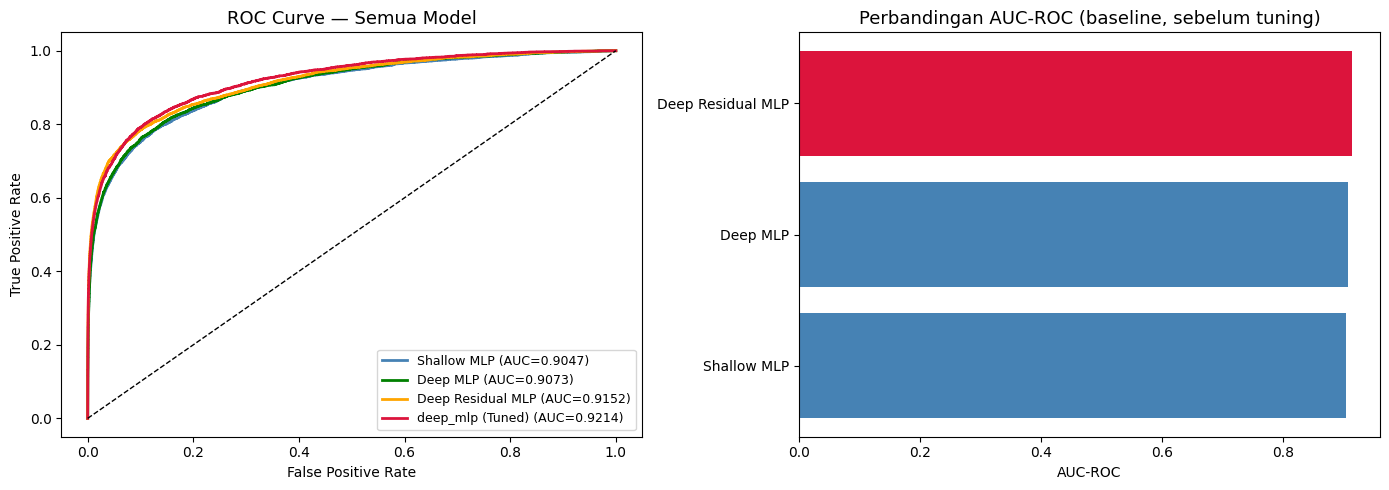

In [31]:
# ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for prob, name, color in [
    (shallow_prob,  "Shallow MLP",                 "steelblue"),
    (deep_prob,     "Deep MLP",                    "green"),
    (residual_prob, "Deep Residual MLP",            "orange"),
    (y_prob_tuned,  f"{best_arch_name} (Tuned)",    "crimson"),
]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={auc:.4f})")

axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Semua Model", fontsize=13)
axes[0].legend(fontsize=9)

# AUC bar (baseline / belum tuning)
res_plot = pd.DataFrame(results).T.sort_values("AUC-ROC", ascending=False)
axes[1].barh(res_plot.index, res_plot["AUC-ROC"].astype(float),
             color=["crimson" if i==0 else "steelblue" for i in range(len(res_plot))])
axes[1].set_title("Perbandingan AUC-ROC (baseline, sebelum tuning)", fontsize=13)
axes[1].set_xlabel("AUC-ROC"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

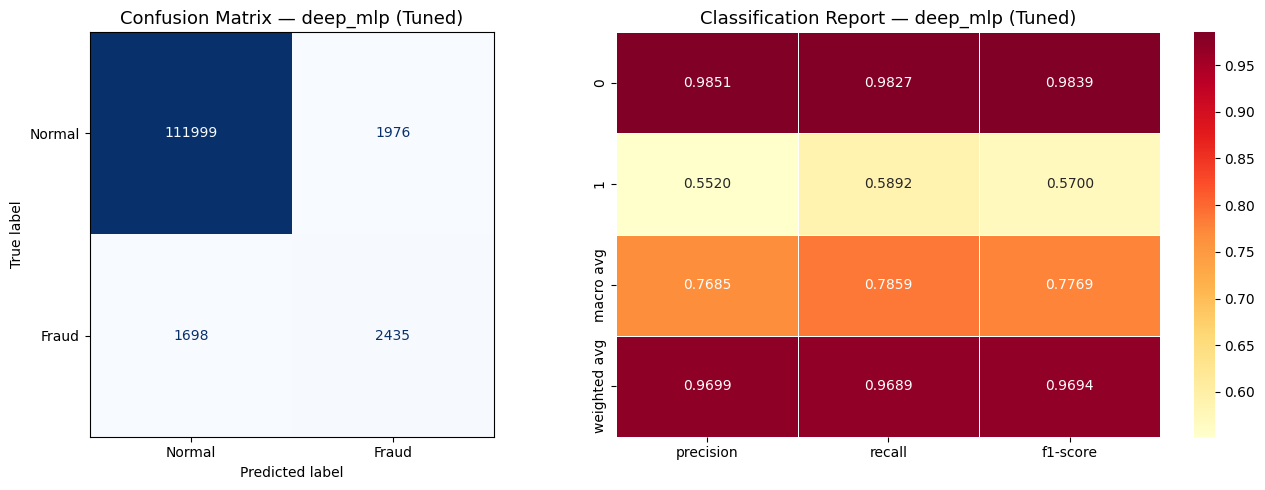


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98    113975
       Fraud       0.55      0.59      0.57      4133

    accuracy                           0.97    118108
   macro avg       0.77      0.79      0.78    118108
weighted avg       0.97      0.97      0.97    118108



In [32]:
# Confusion Matrix
y_pred_best = (y_prob_tuned >= 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=["Normal","Fraud"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_arch_name} (Tuned)", fontsize=13)

report = classification_report(y_val, y_pred_best, output_dict=True)
rep_df = pd.DataFrame(report).T.drop(["accuracy"], errors="ignore")
sns.heatmap(rep_df[["precision","recall","f1-score"]].astype(float).round(4),
            annot=True, fmt=".4f", cmap="YlOrRd", ax=axes[1], linewidths=0.5)
axes[1].set_title(f"Classification Report — {best_arch_name} (Tuned)", fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_val, y_pred_best, target_names=["Normal","Fraud"]))

**Catatan:** *feature importance* khas tree-based model (seperti pada XGBoost) tidak berlaku langsung untuk neural network. Untuk interpretasi model deep learning, pendekatan yang lebih sesuai adalah **permutation importance** atau **SHAP/LIME** — bisa ditambahkan sebagai pengembangan lanjutan jika dibutuhkan (tidak termasuk dalam scope wajib tugas ini).

## 9. 📤 Prediksi Test Set & Submission

In [33]:
print("Memprediksi test set...")

# Ambil kolom yang sama persis dengan training (X_train_sm)
train_features = X_train_sm.columns.tolist()

# Drop TransactionID dan kolom apapun yang tidak ada di training
test_aligned = test.drop(columns=["TransactionID"], errors="ignore")

# Tambah kolom yang ada di train tapi tidak di test (isi 0)
for col in train_features:
    if col not in test_aligned.columns:
        test_aligned[col] = 0

# Buang kolom yang ada di test tapi tidak di train
test_aligned = test_aligned[train_features]

print(f"Test shape setelah align: {test_aligned.shape}")

# Scaling test set dengan scaler yang sama (fit di training)
test_aligned_arr = scaler.transform(test_aligned).astype(np.float32)
test_prob = best_model.predict(test_aligned_arr, verbose=0).ravel()

submission = pd.DataFrame({"TransactionID": test_ids, "isFraud": test_prob})
print(f"Shape submission: {submission.shape}")
print(submission.head())

Memprediksi test set...
Test shape setelah align: (506691, 106)
Shape submission: (506691, 2)
   TransactionID       isFraud
0        3663549  3.628016e-06
1        3663550  1.359189e-09
2        3663551  7.112085e-03
3        3663552  1.348619e-05
4        3663553  1.126496e-01


✅ Submission disimpan ke: /content/drive/MyDrive/submission_fraud_dl.csv


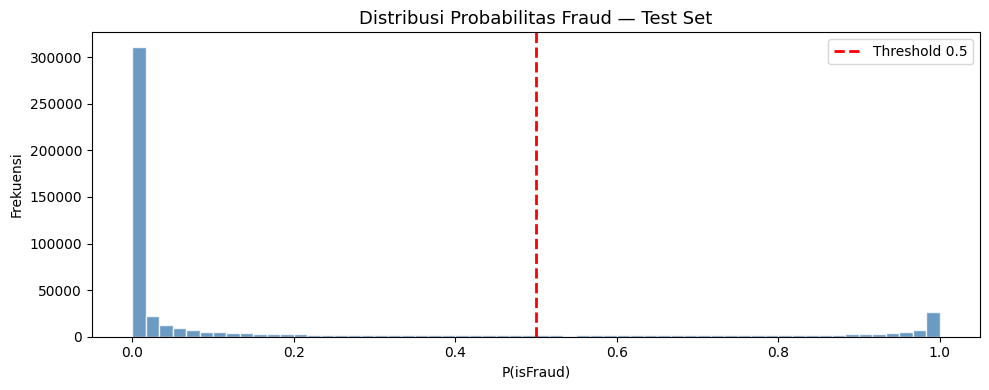

Prediksi fraud: 87,094 (17.19%)


In [34]:
# Simpan ke Drive
sub_path = DRIVE_PATH + "submission_fraud_dl.csv"
submission.to_csv(sub_path, index=False)
print(f"✅ Submission disimpan ke: {sub_path}")

plt.figure(figsize=(10, 4))
plt.hist(test_prob, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(0.5, color="red", linestyle="--", lw=2, label="Threshold 0.5")
plt.title("Distribusi Probabilitas Fraud — Test Set", fontsize=13)
plt.xlabel("P(isFraud)"); plt.ylabel("Frekuensi"); plt.legend()
plt.tight_layout(); plt.show()

fraud_pred = (test_prob >= 0.5).sum()
print(f"Prediksi fraud: {fraud_pred:,} ({fraud_pred/len(test_prob)*100:.2f}%)")

## 10. 📝 Kesimpulan

*(Isi tabel & poin-poin di bawah berdasarkan hasil aktual setelah notebook ini dijalankan penuh di Colab dengan data lengkap — bagian ini hanya kerangka)*

### Rangkuman Hasil Semua Model

| Model | AUC-ROC | F1-Fraud | Avg Precision | Time |
|---|---|---|---|---|
| Shallow MLP | *(isi)* | *(isi)* | *(isi)* | *(isi)* |
| Deep MLP | *(isi)* | *(isi)* | *(isi)* | *(isi)* |
| Deep Residual MLP | *(isi)* | *(isi)* | *(isi)* | *(isi)* |
| **Best Tuned (Optuna)** | *(isi)* | *(isi)* | *(isi)* | — |

---

### Interpretasi (poin yang perlu didiskusikan setelah melihat hasil aktual)

- Arsitektur mana yang menang setelah tuning Optuna — apakah kompleksitas tambahan (Deep MLP / Deep Residual MLP) benar-benar meningkatkan AUC dibanding Shallow MLP, atau peningkatannya tipis?
- Bandingkan **AUC-ROC** sebagai metrik utama (karena dataset sangat imbalanced, hanya ~3.5% fraud dari 590.540 transaksi) — lihat juga **Average Precision** yang lebih sensitif terhadap kelas minoritas.
- Dari confusion matrix: berapa recall fraud yang berhasil dicapai (trade-off precision vs recall pada threshold 0.5 — bisa dieksplorasi threshold lain jika recall masih rendah)?
- Bandingkan hasil ini dengan hasil sebelumnya (XGBoost Tuned, AUC 0.9549) — apakah deep learning sebanding, lebih baik, atau lebih buruk untuk data tabular jenis ini? (Tree-based model seperti XGBoost sering kompetitif atau lebih baik dibanding neural network untuk data tabular dengan banyak fitur kategorikal/sparse seperti dataset ini — ini insight yang umum di literatur, dan layak didiskusikan di laporan.)
- Seluruh eksperimen (parameter & metric tiap trial Optuna, model final) sudah tercatat di MLflow — jalankan `mlflow ui` untuk meninjau ulang.

---

### Optimasi RAM yang Diterapkan

| Teknik | Dampak |
|---|---|
| `dtype downcasting` float64→float32 | 756 MB → 256 MB (hemat 66%) |
| `usecols` — load kolom terpilih saja | Dari 394 kolom → 168 kolom |
| `del train` + `gc.collect()` | Bebaskan RAM segera setelah dipakai |
| `StandardScaler` pada fitur sebelum masuk neural network | Wajib untuk konvergensi training NN yang stabil |

---

### Saran Pengembangan
- Turunkan **threshold** di bawah 0.5 untuk meningkatkan recall fraud (false negative lebih mahal di kasus fraud)
- Tambahkan **permutation importance** atau **SHAP** untuk interpretasi model deep learning
- Tambah **feature engineering** berbasis agregasi (transaksi per kartu, per email domain)
- Gabungkan dengan tabel **identity** untuk fitur tambahan (device, browser, OS)
- Naikkan `N_TRIALS`/`EPOCHS` pada Optuna untuk hasil tuning yang lebih matang jika waktu komputasi memungkinkan